# Fast BOCPD Quickstart

This tutorial shows you how to detect changepoints in time series data using Fast BOCPD.

## What You'll Learn
- Detect changepoints in streaming data
- Visualize results
- Interpret the output

Let's get started!

---

## 1. Installation Check

First, let's make sure Fast BOCPD is installed and working.

**If you get an error below:**
- Run from project root: `cd /path/to/Fast_BOCPD && pip install -e .` and restart notebook kernel.
- Or add to path manually (see error message for instructions)

In [1]:
# Check installation
try:
    from fast_bocpd import BOCPD, GaussianNIG, ConstantHazard, is_available
    assert is_available(), "C library not compiled"
    print("✓ Fast BOCPD is ready!")
except ImportError:
    print("Please install: pip install -e .")
except AssertionError:
    print("C library not compiled. Run: make lib")

✓ Fast BOCPD is ready!


---
## 2. Generate Synthetic Data

Let's create a simple time series with a changepoint in the middle.

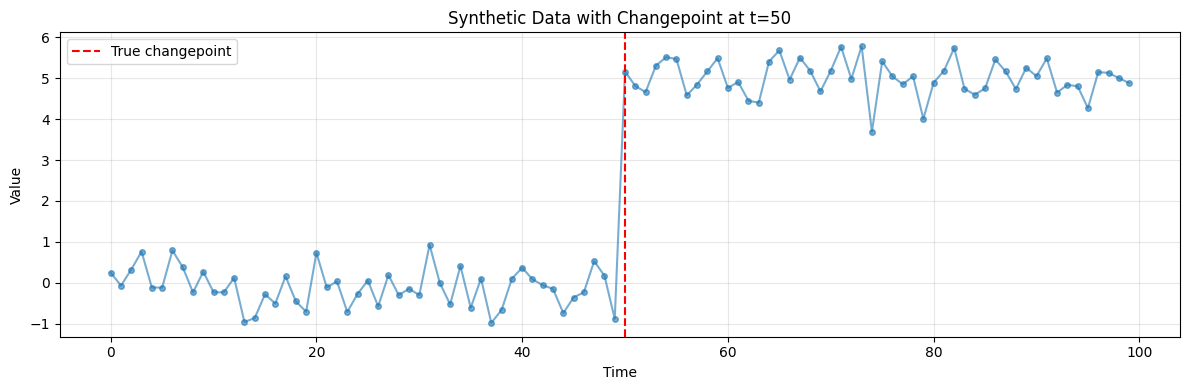

Generated 100 observations
Segment 1 mean: -0.11
Segment 2 mean: 5.01


In [2]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# Generate data: mean=0 for first 50 points, mean=5 for last 50 points
segment_1 = np.random.randn(50) * 0.5 + 0.0  # Low values
segment_2 = np.random.randn(50) * 0.5 + 5.0  # High values
data = np.concatenate([segment_1, segment_2])

# Plot the data
plt.figure(figsize=(12, 4))
plt.plot(data, 'o-', alpha=0.6, markersize=4)
plt.axvline(50, color='red', linestyle='--', label='True changepoint')
plt.xlabel('Time')
plt.ylabel('Value')
plt.title('Synthetic Data with Changepoint at t=50')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Generated {len(data)} observations")
print(f"Segment 1 mean: {segment_1.mean():.2f}")
print(f"Segment 2 mean: {segment_2.mean():.2f}")

---

## 3. Set Up BOCPD

Configure the changepoint detector:
- **GaussianNIG**: Assumes data is normally distributed
- **ConstantHazard**: Expects changepoints every ~50 observations on average
- **max_run_length**: Maximum time between changepoints we'll track

In [3]:
# Configure BOCPD
model = GaussianNIG(
    mu0=0.0,      # Prior mean
    kappa0=1.0,   # Prior precision
    alpha0=1.0,   # Prior shape
    beta0=1.0     # Prior scale
)

hazard = ConstantHazard(lambda_=50)  # Expected run length = 50

bocpd = BOCPD(
    obs_model=model,
    hazard=hazard,
    max_run_length=200
)

print("✓ BOCPD configured and ready")

✓ BOCPD configured and ready


---

## 4. Detect Changepoints (Batch Mode)

Process all the data at once to find changepoints.

In [4]:
# Run BOCPD on the data
cp_probs = bocpd.batch_update(data)

print(f"✓ Processed {len(data)} observations")
print(f"Changepoint probabilities range: [{cp_probs.min():.3f}, {cp_probs.max():.3f}]")

✓ Processed 100 observations
Changepoint probabilities range: [0.001, 0.512]


---

## 5. Visualize Results

Let's plot the data with the detected changepoint probabilities.

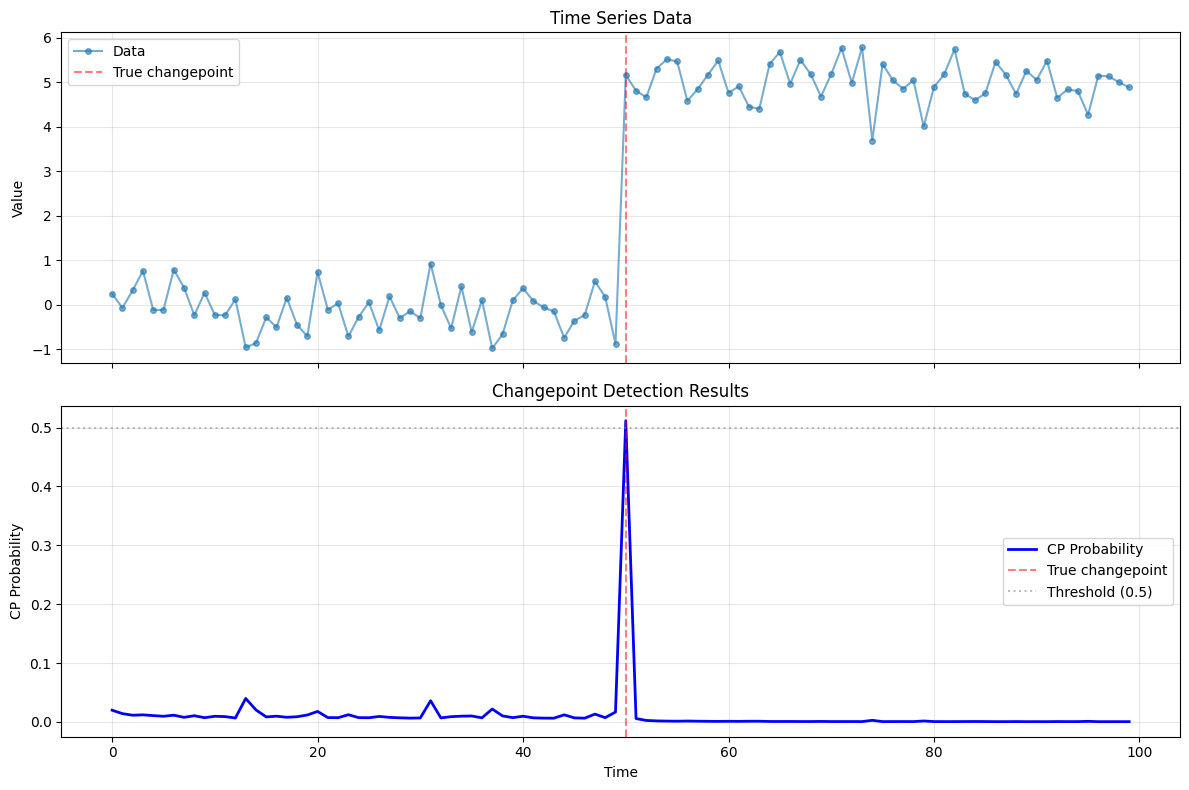


Most likely changepoint at t=50 (true: t=50)
  Confidence: 51.2%


In [5]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Plot 1: Original data
ax1.plot(data, 'o-', alpha=0.6, markersize=4, label='Data')
ax1.axvline(50, color='red', linestyle='--', alpha=0.5, label='True changepoint')
ax1.set_ylabel('Value')
ax1.set_title('Time Series Data')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Changepoint probabilities
ax2.plot(cp_probs, 'b-', linewidth=2, label='CP Probability')
ax2.axvline(50, color='red', linestyle='--', alpha=0.5, label='True changepoint')
ax2.axhline(0.5, color='gray', linestyle=':', alpha=0.5, label='Threshold (0.5)')
ax2.set_xlabel('Time')
ax2.set_ylabel('CP Probability')
ax2.set_title('Changepoint Detection Results')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Find the most likely changepoint
detected_cp = np.argmax(cp_probs)
print(f"\nMost likely changepoint at t={detected_cp} (true: t=50)")
print(f"  Confidence: {cp_probs[detected_cp]:.1%}")

---

## 6. Online Mode (Streaming)

You can also process data one observation at a time (useful for real-time applications).

In [6]:
# Reset and process online
bocpd.reset()

cp_probs_online = []
for t, x in enumerate(data):
    posterior_r, cp_prob = bocpd.update(x)
    cp_probs_online.append(cp_prob)
    
    # Print when high changepoint probability detected
    if cp_prob > 0.5:
        print(f"⚠️  High CP probability at t={t}: {cp_prob:.1%}")

# Verify online matches batch
print(f"\n✓ Online and batch modes give identical results: {np.allclose(cp_probs, cp_probs_online)}")

⚠️  High CP probability at t=50: 51.2%

✓ Online and batch modes give identical results: True


---

## What You Learned
-  Set up BOCPD with GaussianNIG + ConstantHazard
-  Detect changepoints in batch and online modes
-  Visualize and interpret results

### Next Steps
- **02_online_vs_batch.ipynb**: Learn when to use which mode
- **03_understanding_outputs.ipynb**: Deep dive into what BOCPD tells you
- **04_parameter_guide.ipynb**: Learn to configure BOCPD for your data

### Key Takeaway
The spike in changepoint probability at t≈50 correctly identifies where the data shifts from mean=0 to mean=5!